In [6]:
## importing libraries 
import ast
import pandas as pd 
from datasets import load_dataset
import matplotlib.pyplot as plt 

## loading data 
dataset= load_dataset('lukebarousse/data_jobs')
df= dataset['train'].to_pandas()

## data cleaning 
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [7]:
## only get data analyst jobs in the us 
df_DA_US=df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='United States')].copy()

## drop Nan value from the coloumn for plotting 
df_DA_US=df_DA_US.dropna(subset=['salary_year_avg'])

In [12]:
df_DA_US=df_DA_US.explode('job_skills')

df_DA_US[['salary_year_avg','job_skills']]

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel
...,...,...
784882,87500.0,sql
784882,87500.0,vba
784882,87500.0,tableau
784882,87500.0,excel


In [ ]:
## make dataframe for hightest salary median
df_DA_US_group=df_DA_US.groupby('job_skills')['salary_year_avg'].agg(['count','median'])

df_DA_Top_pay=df_DA_US_group.sort_values(by='median',ascending=False).head(10)

df_DA_Top_pay


,count,median
job_skills,,
dplyr,2,196250.0
bitbucket,3,189000.0
gitlab,3,186000.0
solidity,1,179000.0
hugging face,1,175000.0
couchbase,1,160515.0
ansible,1,159640.0
mxnet,2,149000.0
cassandra,6,148250.0


In [21]:
## data frames for skill with highest count 

df_DA_Skills=df_DA_US_group.sort_values(by='count',ascending=False).head(10).sort_values(by='median',ascending=False)

df_DA_Skills

,count,median
job_skills,,
python,1431,97500.00
tableau,1364,92875.00
r,893,92500.00
sql server,286,92500.00
sql,2508,91000.00
sas,926,90000.00
power bi,838,90000.00
powerpoint,462,85000.00
excel,1808,84392.00


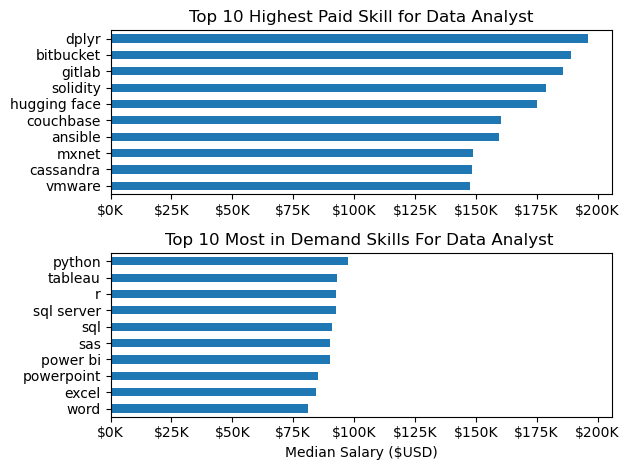

In [34]:
## make two graph subplots 
fig ,ax =plt.subplots(2,1)

## plot the TOP pay  on bar graph 
df_DA_Top_pay[::-1].plot(kind='barh',y='median',ax=ax[0],legend=False)
## set title and labels 
ax[0].set_title('Top 10 Highest Paid Skill for Data Analyst')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x , _ :f'${int(x/1000)}K'))

## plot the TOP skill salary on bar garph 
df_DA_Skills[::-1].plot(kind='barh',y='median',ax=ax[1],legend=False)
## set title and labels 
ax[1].set_title('Top 10 Most in Demand Skills For Data Analyst ')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary ($USD)')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x , _ :f'${int(x/1000)}K'))


## matching the x axis of both the chart to same number so fair to compare 
ax[1].set_xlim(ax[0].get_xlim())

## fig tight layout 
fig.tight_layout()
## showing the chart 
plt.show()